## 1. Линейная регрессия

### 1.1. Загрузка набора данных и проверка его корректности.

In [31]:
import pandas as pd

data = pd.read_csv('lab2_lin1.csv')

print(data.head())

   Unnamed: 0  WorkingAges  LateTimes   KPI  Salary
0           0         20.0       21.0  4.37  3619.6
1           1         24.0       14.0  5.49  5333.7
2           2         22.0       14.0  3.53  3022.7
3           3         26.0       13.0  4.90  5079.7
4           4         18.0       20.0  5.75  4656.0


Набор данных содержит следующие столбцы:
- Unnamed: 0 - индекс строки
- WorkingAges -  стаж работника
- LateTimes - количество опозданий сотрудника
- KPI - показатель эффективности сотрудника
- Salary - ЗП сотрудника

Признаки WorkingAges, LateTimes и KPI потенциально могут влиять на заработную плату сотрудника. Предположим, что Salary - целевая переменная и остальные признаки будут использоваться для ее предсказания.

### 1.2. Разбиение выборки на обучающую и тестовую. Проверка соответствия выборок.

Разделим данные на независимые признаки (X, будет содержать столбцы  WorkingAges, LateTimes и KPI) и на целевую переменную (y, будет содержать столбец Salary). Размер тестовой выборки составляет 20% от всего набора данных.

In [32]:
from sklearn.model_selection import train_test_split

X = data[['WorkingAges', 'LateTimes', 'KPI']]
y = data['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)
print(X.shape, X_train.shape, X_test.shape)

(500, 3) (400, 3) (100, 3)


- (500, 3) - исходный набор данных, содержит 500 объектов по 3 признака; 
- (400, 3) - обучающая выборка; 
- (100, 3) - тестовая выборка.

80% данных используется для обучения, а остальные 20% - для проверки качества обучения

Проверим распределение данных с помощью нормированной гистограммы.

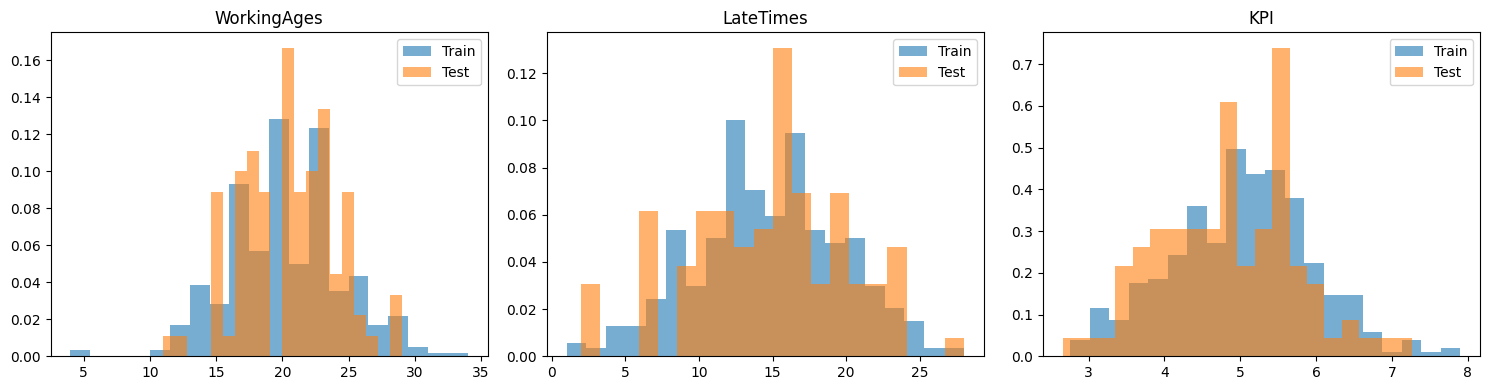

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

for i, col in enumerate(X.columns):
    plt.subplot(1, 3, i+1)
    
    plt.hist(X_train[col], bins=20, alpha=0.6, label='Train', density=True)
    plt.hist(X_test[col], bins=20, alpha=0.6, label='Test', density=True)
    
    plt.title(col)
    plt.legend()

plt.tight_layout()

Из всех графиков видно, что распределения всех признаков в обучающей и тестовой выборке имеют схожий характер.

### 1.3. Проведение линейной регрессии.

In [34]:
from sklearn.linear_model import LinearRegression

model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train)
print(model_lin_reg.coef_)
print(model_lin_reg.intercept_)

[1.72494491e+02 1.51876582e-01 1.06673991e+03]
-4583.211605702219


Полученные коэффициенты показывают степень влияния признаков на целевую переменную. Сделаем следующие выводы:
1) b_1 = 172.49 показывает, что с увеличением стажа на 1 год зарплата растет в соответствии с этим коэффициентом;
2) b_2 = 0.152 показывает, что опоздания практически не влияют на зарплату;
3) b_3 = 1066.74 показывает самое сильное влияние эффективности на зарплату;
4) b_0 = -4583.12 показывает зарплату при нулевых значениях всех признаков (поскольку модель не ограничена - это просто математический результат вычислений).

### 1.4. Рассчет коэффициента детерминации, MAPE и MAE.

In [35]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_train_pred = model_lin_reg.predict(X_train)
y_test_pred = model_lin_reg.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train:.6f}, R2 test: {r2_test:.6f}")
print(f"MAE train: {mae_train:.6f}, MAE test: {mae_test:.6f}")
print(f"MAPE train: {mape_train:.6f}%, MAPE test: {mape_test:.6f}%")

R2 train: 0.998277, R2 test: 0.998126
MAE train: 43.236588, MAE test: 41.802049
MAPE train: 1.138277%, MAPE test: 1.094922%


Модель объясняет 99.8% вариации зарплаты на обучающей выборке и 99.8% на тестовой - модель хорошо улавливает зависимости и правильно обобщает. Средняя ошибка предсказания около 43 ед. зарплаты на обучающей выборке и 41 - на тестовой. MAPE на обучающей и тестовой выборках ~1%, что говорит о высокой точности модели.

### 1.5. Повторение пунктов 1.3 и 1.4 для модификаций линейной регрессии:


#### 1.5.1. Лассо регрессия.

In [36]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

alphas = [0.001, 0.01, 0.1, 1, 10]

lasso = Lasso(max_iter=10000)
grid_lasso = GridSearchCV(lasso, param_grid={'alpha': alphas}, cv=5)
grid_lasso.fit(X_train, y_train)

model_lasso = grid_lasso.best_estimator_

print(model_lasso.alpha)
print(model_lasso.coef_)
print(model_lasso.intercept_)

0.001
[1.72494411e+02 1.51836544e-01 1.06673873e+03]
-4583.203471233154


In [37]:
y_train_pred = model_lasso.predict(X_train)
y_test_pred = model_lasso.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train:.6f}, R2 test: {r2_test:.6f}")
print(f"MAE train: {mae_train:.6f}, MAE test: {mae_test:.6f}")
print(f"MAPE train: {mape_train:.6f}%, MAPE test: {mape_test:.6f}%")

R2 train: 0.998277, R2 test: 0.998126
MAE train: 43.236595, MAE test: 41.802163
MAPE train: 1.138274%, MAPE test: 1.094926%


Модель Lasso на данной выборке аналогична линейной регрессии, поскольку все признаки оказались значимыми и регуляризация не исключила ни одного из них.

#### 1.5.2. Гребневая регрессия.

In [38]:
from sklearn.linear_model import Ridge

ridge = Ridge(max_iter=10000)
grid_ridge = GridSearchCV(ridge, param_grid={'alpha': alphas}, cv=5)
grid_ridge.fit(X_train, y_train)

model_ridge = grid_ridge.best_estimator_

print(model_ridge.alpha)
print(model_ridge.coef_)
print(model_ridge.intercept_)

0.001
[1.72494445e+02 1.51855071e-01 1.06673680e+03]
-4583.194756520265


In [39]:
y_train_pred = model_ridge.predict(X_train)
y_test_pred = model_ridge.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train:.6f}, R2 test: {r2_test:.6f}")
print(f"MAE train: {mae_train:.6f}, MAE test: {mae_test:.6f}")
print(f"MAPE train: {mape_train:.6f}%, MAPE test: {mape_test:.6f}%")

R2 train: 0.998277, R2 test: 0.998126
MAE train: 43.236623, MAE test: 41.802382
MAPE train: 1.138272%, MAPE test: 1.094932%


Модель Ridge на данной выборке ведёт себя аналогично линейной регрессии, поскольку все признаки значимы, а регуляризация лишь слегка снижает величину коэффициентов, не исключая ни одного признака.

#### 1.5.3. ElasticNet.

In [40]:
from sklearn.linear_model import ElasticNet

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

param_grid = {
    'alpha': alphas,
    'l1_ratio': l1_ratios
}

elastic = ElasticNet(max_iter=10000)
grid_elastic = GridSearchCV(elastic, param_grid=param_grid, cv=5)
grid_elastic.fit(X_train, y_train)

model_elastic = grid_elastic.best_estimator_

print(model_elastic.alpha)
print(model_elastic.l1_ratio)
print(model_elastic.coef_)
print(model_elastic.intercept_)

0.001
0.9
[1.72492590e+02 1.50980899e-01 1.06661452e+03]
-4582.53036458091


In [41]:
y_train_pred = model_elastic.predict(X_train)
y_test_pred = model_elastic.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train:.6f}, R2 test: {r2_test:.6f}")
print(f"MAE train: {mae_train:.6f}, MAE test: {mae_test:.6f}")
print(f"MAPE train: {mape_train:.6f}%, MAPE test: {mape_test:.6f}%")

R2 train: 0.998277, R2 test: 0.998125
MAE train: 43.238005, MAE test: 41.815448
MAPE train: 1.138075%, MAPE test: 1.095335%


Регуляризация уменьшает величины коэффициентов и может снижать влияние некоторых признаков, однако в данном наборе данных влияние регуляризации незначительно, поэтому коэффициенты остаются близкими к коэффициентам обычной линейной регрессии. По значениям метрик качества модель показывает результаты, практически совпадающие с линейной, Lasso и Ridge регрессиями. Небольшое снижение показателей объясняется более сильным сжатием коэффициентов из-за комбинированной регуляризации.

### 1.6. Построение таблицы для рассчитываемых метрик и используемых методов.

Построим heatmap для проверки корреляции между признаками.

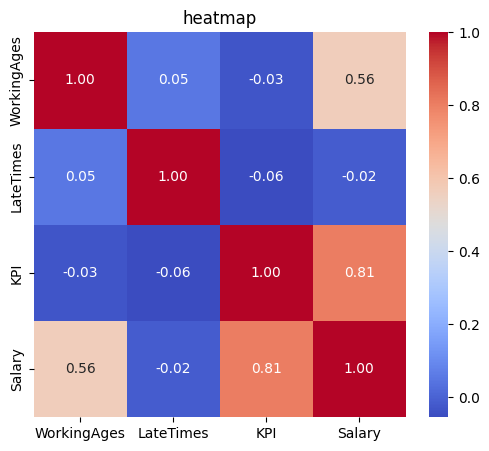

In [42]:
import seaborn as sns

corr = data[['WorkingAges', 'LateTimes', 'KPI', 'Salary']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("heatmap")
plt.show()

По тепловой карте видно, что показатель KPI имеет наиболее сильную положительную корреляцию с заработной платой (Salary). Признак WorkingAges также положительно коррелирует с зарплатой, но слабее. Признак LateTimes имеет слабую связь с целевой переменной, что подтверждает ранее полученные коэффициенты регрессии.

### 1.7. Построение диаграммы рассеяния  между предикаторами и откликом для модели с лучшим результатом.

В п. 1.6. линейная регрессия была определена лучшей моделью, поэтому построим диаграмму рассеяния для нее.

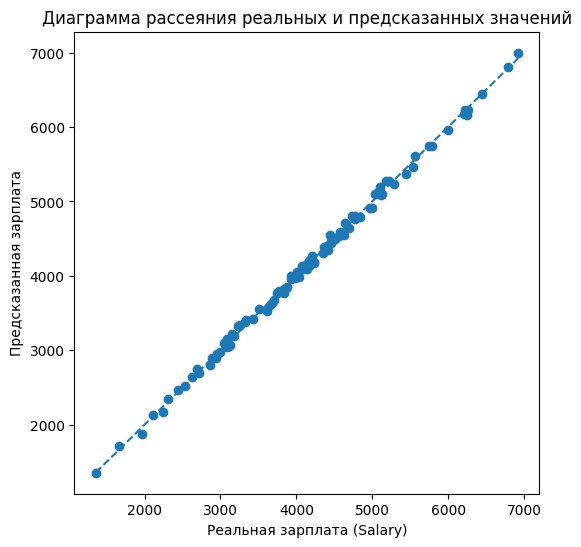

In [43]:
import matplotlib.pyplot as plt

y_pred = model_lin_reg.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Реальная зарплата (Salary)")
plt.ylabel("Предсказанная зарплата")
plt.title("Диаграмма рассеяния реальных и предсказанных значений")

plt.show()

По диаграмме видно, что точки расположены близко к диагональной линии, что говорит о высокой точности модели. Предсказанные значения практически совпадают с реальными значениями заработной платы. Это подтверждает ранее полученные значения метрик качества.
Получается, построенная модель линейной регрессии хорошо описывает зависимость между признаками и целевой переменной и обладает хорошей обобщающей способностью.

## 2. Нелинейная регрессия

### 2.1. Загрузка набора данных и проверка его корректности.

In [44]:
data_poly = pd.read_csv('lab2_poly2.csv')

print(data_poly.head())

   Unnamed: 0  Experience        Salary
0           0   34.148659  35186.143515
1           1   39.429129  45366.424097
2           2   13.837876  65664.538074
3           3   31.028990  36133.821589
4           4   25.258173  53814.594836


Признак Expirience используется в качестве независимой переменной, а Salary - в качестве целевой переменной, которую требуется предсказать

### 2.2. Разбиение выборки на обучающую и тестовую. Проверка соответствия выборок.

In [45]:
X = data_poly[['Experience']]
y = data_poly['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X.shape, X_train.shape, X_test.shape)

(500, 1) (400, 1) (100, 1)


В результате разбиения получены аналогичные размеры выборок, что и в п. 1.2 - 80% данных используется для обучения, а остальные 20% - для проверки качества обучения.

Проверим распределение данных с помощью нормированной гистограммы.

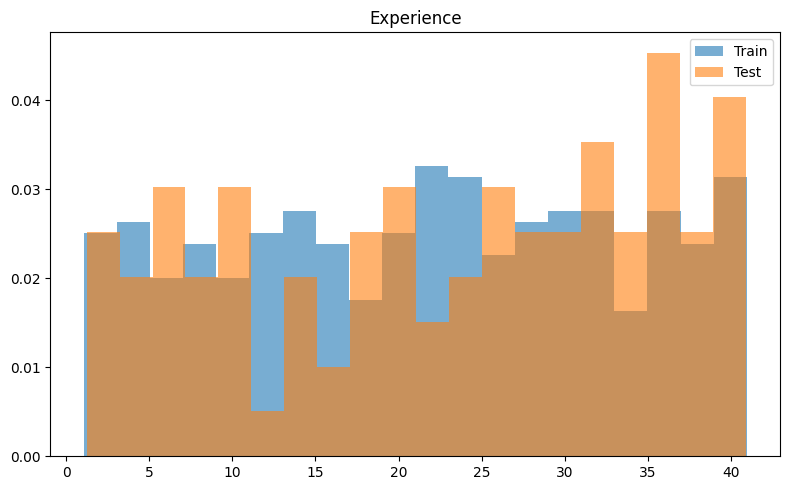

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(X_train['Experience'], bins=20, alpha=0.6, label='Train', density=True)
plt.hist(X_test['Experience'], bins=20, alpha=0.6, label='Test', density=True)
plt.title('Experience')
plt.legend()
plt.tight_layout()
plt.show()

Гистограммы показывают, что обучающая и тестовая выборки имеют схожие распределения: одинаковый диапазон значений признаков, аналогичную структуру с локальными экстремумами. Данные обеих выборок равномерно перекрываются - это показывает корректность разбиения.

### 2.3. Проверка загруженных данных на линейной регрессии. Построение диаграммы рассеяния данных.

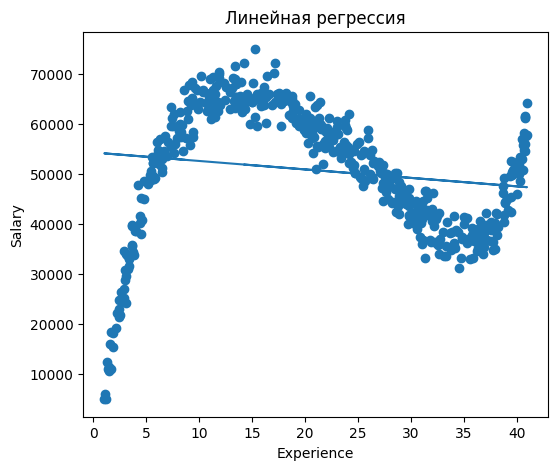

In [ ]:
model_lin_reg_poly = LinearRegression()
model_lin_reg_poly.fit(X_train, y_train)
y_pred_poly = model_lin_reg_poly.predict(X_train)

plt.figure(figsize=(6,5))
plt.scatter(X, y)
plt.plot(X_train, y_pred_poly)
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Линейная регрессия")
plt.show()

### 2.4. Нахождение степени полинома.

Создадим полиномиальные признаки, чтобы линейная регрессия могла описывать нелинейную зависимость между переменными. Обучим модели для разных степеней полинома и сравним коэффициент детерминации на обучающей и тестовой выбоках, чтобы определить оптимальную сложность модели и момент начала переобучения.

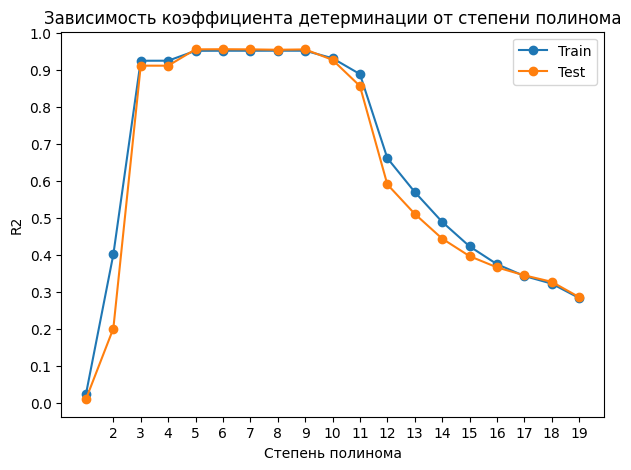

In [48]:
from sklearn.preprocessing import PolynomialFeatures

r2_train_list = []
r2_test_list = []

for d in range(1, 20):
    
    poly = PolynomialFeatures(degree=d)
    
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    r2_train_list.append(r2_score(y_train, y_train_pred))
    r2_test_list.append(r2_score(y_test, y_test_pred))

plt.figure(figsize=(7,5))
plt.plot(range(1, 20), r2_train_list, marker='o', label="Train")
plt.plot(range(1, 20), r2_test_list, marker='o', label="Test")
plt.xticks(range(2, 20))
plt.yticks(np.arange(0.0, 1.01, 0.1))
plt.xlabel("Степень полинома")
plt.ylabel("R2")
plt.title("Зависимость коэффициента детерминации от степени полинома")
plt.legend()
plt.show()

До 5 степени полинома значение R2 на обучающей и тестовой выборказ быстро растет (с 0.0 до > 0.9) и практически совпадает, что говорит о недостаточно сложности модели. В диапазоне 5-9 степеней значение R² стабилизируется на высоком уровне (~0.95) для обеих выборок, что указывает на оптимальную степень полинома. Начиная с 10 степени, значение R² на тестовой выборке начинает резко уменьшаться, а разрыв между обучающей и тестовой выборками растет - это говорит о переобучении модели.
Выберу степень полинома 6, так как в этой точке коэффициент детерминации на обучающей и тестовой выборках принимает высокие и близкие значения.

### 2.5. Рассчет и анализ полученных коэффициентов. Рассчет значений метрик коэффициента детерминации, MAPE и MAE.

Создадим полиномиальные признаки (6) и обучим линейную регрессию на них.

In [49]:
degree = 6

poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

print(f"b_0: {model.intercept_}")
for i, coef in enumerate(model.coef_):
    if i!=0:
        print(f"b_{i}: {coef}")

b_0: -10966.609387158358
b_1: 17444.974266272373
b_2: -1472.9341140838478
b_3: 57.88647802950614
b_4: -0.9984488980864938
b_5: 9.33270362111216e-05
b_6: 0.00013731226135860197


In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train:.6f}, R2 test: {r2_test:.6f}")
print(f"MAE train: {mae_train:.6f}, MAE test: {mae_test:.6f}")
print(f"MAPE train: {mape_train:.6f}%, MAPE test: {mape_test:.6f}%")

R2 train: 0.951393, R2 test: 0.955516
MAE train: 2275.845058, MAE test: 2087.411498
MAPE train: 4.924428%, MAPE test: 4.939506%


Модель объясняет 95.1% данных на обучающей выборке и 95.6% на тестовой - модель не переобучена, так как метрики на тестовой выборке не хуже, чем на обучающей. Небольшое улучшение качества на тесте может быть связано с особенностями разбиения данных. Средняя ошибка предсказания 2275.85 на обучающей выборке и 2087.41 - на тестовой. MAPE на обучающей и тестовой выборках ~5%, что указывает на высокую точность прогноза модели.

### 2.6. Построение диаграммы рассеяния данных с линией полинома.

Построим график с точками рассеяния данных и с предсказанием обученной модели.

/home/ksenia/.local/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


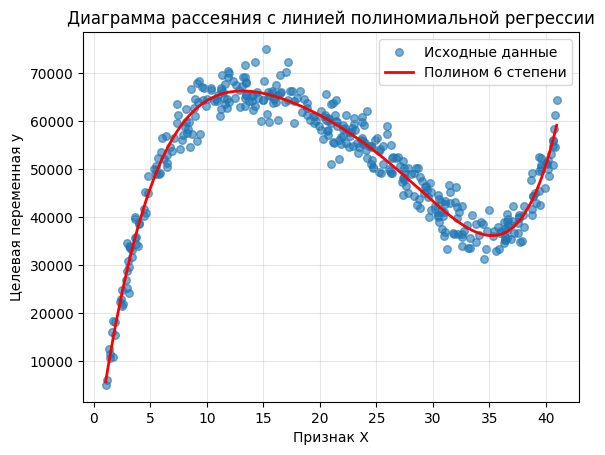

In [51]:
plt.scatter(X_train, y_train, alpha=0.6, label='Исходные данные', s=30)

X_train_sorted = np.sort(X_train, axis=0)
X_train_poly_sorted = poly.transform(X_train_sorted)
y_pred_sorted = model.predict(X_train_poly_sorted)

plt.plot(X_train_sorted, y_pred_sorted, color='red', linewidth=2, label='Полином 6 степени')

plt.xlabel('Признак X')
plt.ylabel('Целевая переменная y')
plt.title('Диаграмма рассеяния с линией полиномиальной регрессии')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Полином 6 степени хорошо описывает данные: кривая полинома проходит через центр облака точек и правильно повторяет нелинейный характер данных. Точки равномерно распределены относительно кривой по всей длине графика - нет областей, где модель занижает или завышает предсказания. Разброс точек выглядит случайным, без явных паттернов. Плавность кривой без резких колебаний подтверждает отсутствие переобучения. Визуальное качество моделирования соответствует высоким значениям метрик (R2 ~ 95.5%, MAPE ~ 5%), рассчитанных в п. 2.5.

### 2.7. Для выбранной степени полинома, решите задачу нелинейной регрессии без конструирования полиномиальных признаков и используя библиотеку TensorFlow.

Решим задачу нелинейной регрессии через библиотеку TensorFlow.

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

X_train_tf = tf.constant(X_train_scaled, dtype=tf.float32)
y_train_tf = tf.constant(y_train_scaled, dtype=tf.float32)

num_coef = 7
w = tf.Variable(tf.zeros([num_coef], dtype=tf.float32))

def model_tf(x):
    y_pred = 0
    for i in range(num_coef):
        y_pred += w[i] * x**i
    return y_pred

optimizer = tf.optimizers.Adam(0.01)

for epoch in range(5000):
    with tf.GradientTape() as tape:
        y_pred = model_tf(X_train_scaled)
        loss = tf.reduce_mean((y_train_scaled - y_pred)**2)

    grads = tape.gradient(loss, [w])
    optimizer.apply_gradients(zip(grads, [w]))

w_values = w.numpy()
for i in range(len(w_values)):
    print(f"b_{i}: {w_values[i]}")

b_0: 0.6590833067893982
b_1: -1.264103651046753
b_2: -0.6078616976737976
b_3: -0.02942206710577011
b_4: -0.05630442872643471
b_5: 0.28190600872039795
b_6: 0.02516642026603222


Сначала данные X и y стандартизируются с помощью StandartScaler. Затем создаем полином степени 6 с коэффициентами w, которые обучаются градиеньным спуском с оптимизатором Adam (минимизирует среднеквадратичную ошибку). Через цикл GradientTape вычисляем градиенты и обновляем w на каждой эпохе, а после обучения выводим коэффициенты в виде массива.

### 2.8. Рассчет метрик коэффициента детерминации, MAPE, MAE. Построение диаграммы рассеяния для полученных данных.

In [53]:
y_train_pred_scaled = model_tf(X_train_tf).numpy()
y_test_pred_scaled = model_tf(tf.constant(X_test_scaled, dtype=tf.float32)).numpy()

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

y_train_pred = y_train_pred.ravel()
y_test_pred = y_test_pred.ravel()

r2_train_tf = r2_score(y_train, y_train_pred)
r2_test_tf = r2_score(y_test, y_test_pred)

mae_train_tf = mean_absolute_error(y_train, y_train_pred)
mae_test_tf = mean_absolute_error(y_test, y_test_pred)

mape_train_tf = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
mape_test_tf = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"R2 train: {r2_train_tf:.6f}, R2 test: {r2_test_tf:.6f}")
print(f"MAE train: {mae_train_tf:.6f}, MAE test: {mae_test_tf:.6f}")
print(f"MAPE train: {mape_train_tf:.6f}%, MAPE test: {mape_test_tf:.6f}%")


R2 train: 0.951393, R2 test: 0.955514
MAE train: 2275.802041, MAE test: 2087.433285
MAPE train: 4.923855%, MAPE test: 4.938934%


Коэффициент детерминации R2 показывает, что модель объясняет около 95% вариации зарплаты как на тренировочной выборке (R2 train ~ 0.951), так и на тестовой (R2 test ~ 0.956), что указывает на отсутствие переобучения. Средняя абсолютная ошибка MAE также сопоставима для обучения и теста (MAE train ~ 2276 и MAE test ~ 2087), что подтверждает стабильность предсказаний. MAPE ~ 5% показывает небольшую относительную ошибку и схожие значения для обеих выборок, что дополнительно подтверждает точность модели.

Построим диаграмму рассеяния с предсказаниями TensorFlow модели.

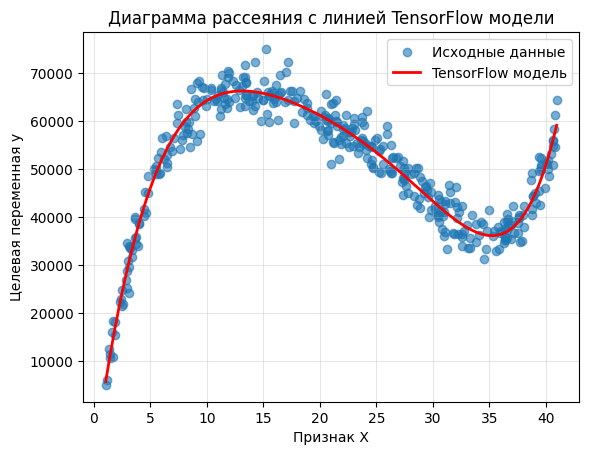

In [54]:
X_train_sorted = np.sort(X_train_scaled.squeeze())
y_pred_sorted = model_tf(tf.constant(X_train_sorted, dtype=tf.float32)).numpy()

X_plot_scaled = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 300).reshape(-1, 1)
y_plot_pred_scaled = model_tf(tf.constant(X_plot_scaled, dtype=tf.float32)).numpy()

X_plot_original = scaler_X.inverse_transform(X_plot_scaled)    
y_plot_pred_original = scaler_y.inverse_transform(y_plot_pred_scaled)

plt.scatter(X_train, y_train, alpha=0.6, label='Исходные данные')
plt.plot(X_plot_original, y_plot_pred_original, color='red', linewidth=2, label='TensorFlow модель')
plt.title('Диаграмма рассеяния с линией TensorFlow модели')
plt.xlabel('Признак X')
plt.ylabel('Целевая переменная y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

TensorFlow модель также хорошо описывает данные: кривая проходит через центр облака точек и корректно воспроизводит нелинейный характер зависимости. Точки равномерно распределены относительно кривой без систематических отклонений, разброс выглядит случайным, а плавность кривой подтверждает отсутствие переобучения. Визуальное качество моделирования соответствует высоким значениям метрик (R2 ~ 95.1%, MAPE ~ 5%), рассчитанных в п. 2.8.

### 2.9. Сравнение результатов, полученных с/без конструирования полиномиальных признаков.

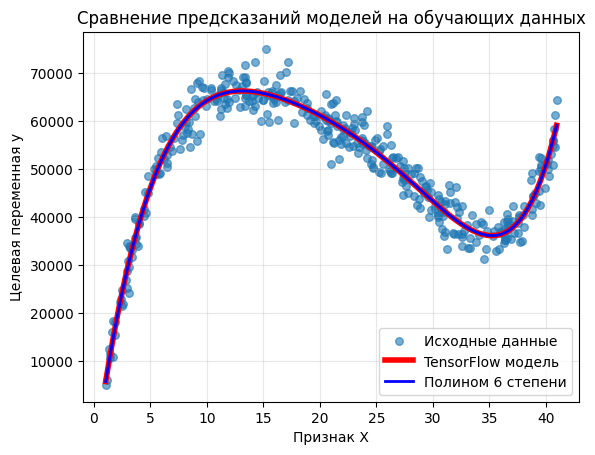

In [55]:
X_sorted_original = scaler_X.inverse_transform(X_train_sorted.reshape(-1, 1))
y_pred_sorted_original = scaler_y.inverse_transform(y_pred_sorted.reshape(-1, 1))

plt.scatter(X_train, y_train, alpha=0.6, label='Исходные данные', s=30)

plt.plot(X_plot_original, y_plot_pred_original, color='red', linewidth=4, label='TensorFlow модель')
plt.plot(X_sorted_original, y_pred_sorted_original, color='blue', linewidth=2, label='Полином 6 степени')

plt.xlabel('Признак X')
plt.ylabel('Целевая переменная y')
plt.title('Сравнение предсказаний моделей на обучающих данных')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Метрики и график показывают, что обе модели практически одинаковые: значения R2 совпадают до 4-го знака (~ 0.9514 / ~ 0.9555), MAE различается менее чем на 0.05, а MAPE - менее чем на 0.001%. На графике кривые полиномиальной регрессии и TensorFlow модели полностью накладываются друг на друга, что визуально подтверждает совпадение метрик. Это объясняется тем, что обе модели по сути являются полиномами 6 степени - разница только в способе нахождения коэффициентов: аналитическое решение через конструирование признаков и численная оптимизация градиентным спуском в TensorFlow. Оба метода привели к практически одинаковому результату.